# Clasificación de Tipo y Subtipo de Violencia en Colombia
### RoBERTa (PlanTL-GOB-ES/roberta-base-bne) + Clasificación Jerárquica
**Autor:** Johan Camilo Balanta Santacruz  
**Universidad San Buenaventura, Cali**

> Versión mejorada: reemplaza el BiLSTM+Atención por fine-tuning completo de RoBERTa en español,
> conservando la clasificación jerárquica, pesos de clase, early stopping y división estratificada.

## Celda 1 — Instalación de dependencias

Instala las bibliotecas necesarias:
- **transformers / tokenizers**: modelo RoBERTa y tokenizador de HuggingFace.
- **pandas / numpy**: manipulación de datos.
- **scikit-learn**: codificación de etiquetas, división y métricas.
- **torch**: framework de Deep Learning.
- **matplotlib / seaborn**: visualizaciones.

In [ ]:
!pip install transformers tokenizers pandas numpy scikit-learn torch matplotlib seaborn -q

## Celda 2 — Importaciones y configuración de semillas

Se importan todos los módulos y se fija la semilla aleatoria (`SEED=42`) para reproducibilidad.  
Se detecta automáticamente si hay GPU disponible (`DEVICE`).

In [ ]:
import re
import math
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Dispositivo: cuda
GPU: Tesla T4
VRAM disponible: 15.6 GB


## Celda 3 — Carga del dataset

Se monta Google Drive y se carga el CSV `monitor-eventos-2024-violencia.csv` separado por `;`.  
Las tres columnas clave son:
- **`Descripcion de la fuente`**: texto libre del evento (entrada del modelo).
- **`Categorias`**: tipo principal de violencia.
- **`Subcategorias`**: subtipo específico.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/monitor-eventos-2024-violencia (1).csv',
    sep=';',
    encoding='utf-8',
    on_bad_lines='skip'
)

TEXT_COL   = 'Descripcion de la fuente'
CAT_COL    = 'Categorias'
SUBCAT_COL = 'Subcategorias'

print(f'Registros cargados: {len(df):,}')
print(f'Columnas:           {list(df.columns)}')
print(f'\nEjemplo de texto:\n{df[TEXT_COL].iloc[0]}')
print(f'Categoría:     {df[CAT_COL].iloc[0]}')
print(f'Subcategoría:  {df[SUBCAT_COL].iloc[0]}')

Registros cargados: 4,272
Columnas:           ['Id de evento', 'Tipo', 'Fecha Evento', 'Fecha Final de Evento', 'Título evento', 'Descripcion y Resumen Evento', 'Categorias', 'Subcategorias', 'Doble/Multiple Afectacion', 'Resolucion 1612', 'Resolucion 1820', 'Descripcion de la fuente', 'Divipola Dpto', 'Departmento', 'Divipola Municipio', 'Municipio', 'Numero de afectados', 'Genero', 'Familia', 'Ocupacion', 'Etnia', 'Grupo poblacional', 'Edad', 'Estado', 'Condicion', 'Departamento receptor', 'Municipio receptor', 'Numero de personas recibidas', 'Fecha de fuente', 'Tipo de fuente', 'Nombre de fuente', 'Fuente', 'Fecha de corte']

Ejemplo de texto:
Un ataque con explosivos contra una unidad militar de la Décima Séptima Brigada que se movilizaba en la vereda Los Enamorados de Turbo dejó un soldado muerto y otros 12 uniformados heridos en la madrugada de este miércoles, 3 de enero, en el Urabá antioqueño, según denunció el Ejército Nacional. 
Categoría:     Acciones armadas
Subcategoría:  

## Celda 4 — Distribución de clases

Muestra la distribución original de categorías y subcategorías.  
Revela el **desbalance de clases** que motiva el uso de pesos en la función de pérdida.

=== CATEGORÍAS ===
Categorias
Ataques contra la población civil        2053
Acciones armadas                          788
Restricción al acceso humanitario         625
Desplazamiento forzado                    355
Uso de artefactos explosivos              328
Categorías Complementarias                 62
Ataque a objetivos ilícitos de guerra      60
Name: count, dtype: int64

=== SUBCATEGORÍAS ===
Subcategorias
Homicidio intencional en persona protegida                                                                                       923
Amenazas (individuales/colectivas)                                                                                               309
Desplazamientos masivos                                                                                                          278
Combates                                                                                                                         265
Confinamiento/Bloqueo de comunidades                 

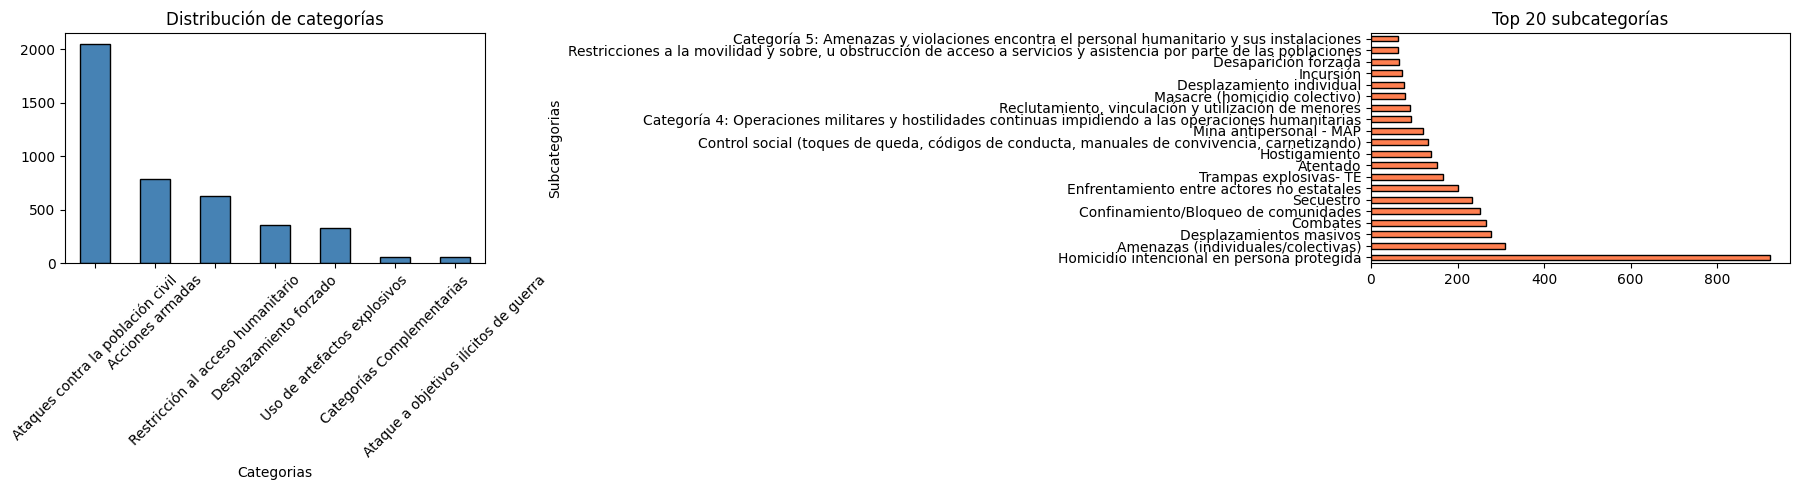

In [ ]:
print('=== CATEGORÍAS ===')
print(df[CAT_COL].value_counts())
print('\n=== SUBCATEGORÍAS ===')
print(df[SUBCAT_COL].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
df[CAT_COL].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de categorías')
axes[0].tick_params(axis='x', rotation=45)

df[SUBCAT_COL].value_counts().head(20).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 20 subcategorías')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 5 — Limpieza y filtrado

Elimina filas nulas o textos muy cortos (≤ 10 caracteres).  
Aplica un **umbral mínimo de 50 ejemplos por subcategoría**: clases con menos registros
se descartan porque el modelo no puede aprender patrones confiables.

> A diferencia del BiLSTM, RoBERTa no necesita limpieza agresiva del texto (URLs, puntuación)
> porque su tokenizador BPE maneja esos caracteres. Solo se normaliza el espacio en blanco.

In [ ]:
MIN_EJEMPLOS_SUBCAT = 60

df = df.dropna(subset=[TEXT_COL, CAT_COL, SUBCAT_COL])
df = df[df[TEXT_COL].str.strip().str.len() > 10].reset_index(drop=True)

# Filtrado de subcategorías con pocos ejemplos
conteo_subcat  = df[SUBCAT_COL].value_counts()
subcat_validas = conteo_subcat[conteo_subcat >= MIN_EJEMPLOS_SUBCAT].index
df_sub = df[df[SUBCAT_COL].isin(subcat_validas)].reset_index(drop=True)

print(f'Registros para categoría:                          {len(df):,}')
print(f'Registros para subcategoría (>={MIN_EJEMPLOS_SUBCAT} ejemplos): {len(df_sub):,}')
print(f'Subcategorías conservadas: {df_sub[SUBCAT_COL].nunique()} de {df[SUBCAT_COL].nunique()}')
print(f'\nSubcategorías eliminadas:')
print(conteo_subcat[conteo_subcat < MIN_EJEMPLOS_SUBCAT].index.tolist())

# Limpieza mínima: solo normalizar espacios (RoBERTa maneja el resto)
def limpiar_texto(texto):
    texto = str(texto).strip()
    texto = re.sub(r'\s+', ' ', texto)
    return texto

df['texto_limpio']     = df[TEXT_COL].apply(limpiar_texto)
df_sub['texto_limpio'] = df_sub[TEXT_COL].apply(limpiar_texto)
print('\nLimpieza de texto aplicada.')

Registros para categoría:                          4,114
Registros para subcategoría (>=50 ejemplos): 3,626
Subcategorías conservadas: 20 de 41

Subcategorías eliminadas:
['Ataque, ocupación o uso infraestructura y/o bienes civiles (incluye bienes culturales y religiosos)', 'Categoría 3: Restricciones o interferencia con el paso de agencias, personal o bienes en el país', 'Bloqueo de vías y/o Retén ilegal', 'Desvinculación de menores de edad', 'Munición sin explotar - MSE', 'Categoría 6: Interferencia en la implementación de actividades/acción humanitaria', 'Ataque a infraestructura militar / policial', 'Impacto por movilización social/protestas', 'Categoría 5.1: Ataques contra misión médica', 'Paro armado', 'Emboscada', 'Categoría 7: Presencia de Minas Antipersonales (MAP) y Municiones Sin Explotar (MUSE)', 'Tortura', 'Categoría 8: Ambiente físico/Estado de infraestructura física', 'Ataques a bienes indispensables para la superviviencia de la población civil', 'Categoría 1: Negación p

## Celda 6 — Tokenizador RoBERTa

Se carga el tokenizador de `PlanTL-GOB-ES/roberta-base-bne`, entrenado sobre
el Boletín Oficial del Estado español y corpus periodísticos — dominio cercano
al texto legal/formal de eventos de violencia.

**Diferencias clave vs. tokenización manual:**
- Usa **BPE (Byte-Pair Encoding)**: maneja palabras OOV y morfología sin diccionario propio.
- Añade automáticamente los tokens especiales `<s>` (inicio) y `</s>` (fin).
- `MAX_LEN=256` tokens cubre el percentil 95 de descripciones en la mayoría de datasets de este tipo;
  si tus textos son más largos ajusta hasta 512 (límite del modelo, más VRAM requerida).

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (588 > 512). Running this sequence through the model will result in indexing errors


=== Longitud de tokens (tokenizador RoBERTa) ===
count    4114.000000
mean      111.379922
std        98.484385
min         5.000000
25%        52.000000
50%        84.000000
75%       135.000000
max       973.000000
Name: texto_limpio, dtype: float64

Percentil 95: 292 tokens  →  MAX_LEN=256


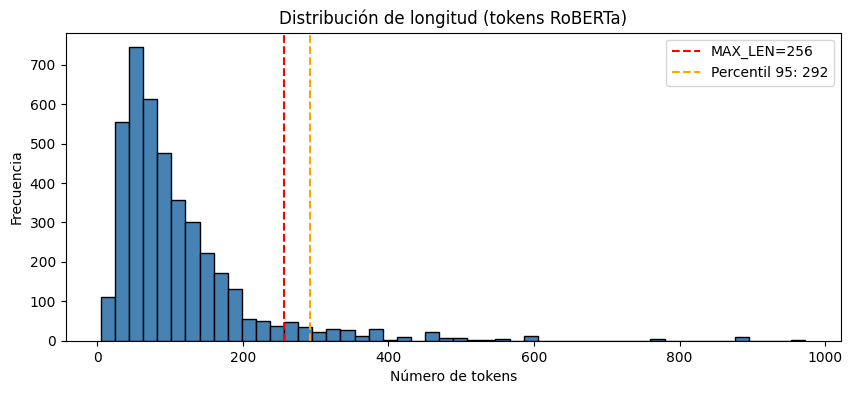

In [ ]:
MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
MAX_LEN    = 256   # aumentar a 512 si los textos son muy largos (más VRAM)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Verificar longitud de textos con el tokenizador real
longitudes = df['texto_limpio'].apply(
    lambda t: len(tokenizer.encode(t, add_special_tokens=True)))
print('=== Longitud de tokens (tokenizador RoBERTa) ===')
print(longitudes.describe())
p95 = int(longitudes.quantile(0.95))
print(f'\nPercentil 95: {p95} tokens  →  MAX_LEN={MAX_LEN}')

plt.figure(figsize=(10, 4))
plt.hist(longitudes, bins=50, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.axvline(p95,     color='orange', linestyle='--', label=f'Percentil 95: {p95}')
plt.title('Distribución de longitud (tokens RoBERTa)')
plt.xlabel('Número de tokens')
plt.ylabel('Frecuencia')
plt.legend()
plt.savefig('longitud_tokens_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 7 — Data augmentation

Define tres estrategias de aumento de datos para clases con pocos ejemplos (< `AUG_THRESHOLD = 100`).

> **Nota:** Con RoBERTa el umbral baja de 150 a 100 porque el modelo preentrenado
> ya aporta mucho conocimiento semántico y necesita menos ejemplos para aprender cada clase.
> El augmentation solo se aplica a subcategorías; para categoría RoBERTa es suficientemente
> robusto con los datos originales.

| Estrategia | Qué hace |
|---|---|
| **swap** | Intercambia dos palabras al azar |
| **delete** | Elimina palabras con probabilidad `AUG_P=0.15` |
| **synonym** | Reemplaza palabras clave por sinónimos del dominio |

In [ ]:
AUG_THRESHOLD = 100   # umbral reducido vs BiLSTM (RoBERTa necesita menos ejemplos)
AUG_TARGET    = 100
AUG_P         = 0.15

SINONIMOS = {
    'asesinado': ['muerto', 'fallecido', 'ultimado', 'homicidado'],
    'muerto':    ['fallecido', 'asesinado', 'víctima'],
    'disparos':  ['tiros', 'balas', 'impactos'],
    'atacar':    ['agredir', 'arremeter', 'hostigar'],
    'ataque':    ['agresión', 'hostigamiento', 'arremetida'],
    'zona':      ['área', 'sector', 'región'],
    'rural':     ['campesino', 'vereda', 'campo'],
    'armado':    ['armados', 'milicianos', 'combatientes'],
    'grupo':     ['banda', 'organización', 'frente'],
    'herido':    ['lesionado', 'heridos', 'afectado'],
    'desplazado':['desplazados', 'desplazamiento', 'refugiado'],
    'amenaza':   ['amenazas', 'intimidación', 'hostigamiento'],
    'secuestro': ['plagio', 'retención', 'rapto'],
    'explosión': ['detonación', 'estallido', 'explosivo'],
    'mina':      ['artefacto', 'explosivo', 'mina antipersona'],
    'persona':   ['individuo', 'sujeto', 'ciudadano'],
    'hombre':    ['hombre', 'varón', 'masculino'],
    'mujer':     ['dama', 'femenino', 'señora'],
}

def swap_words(words):
    if len(words) < 2: return words
    w = words[:]
    i, j = random.sample(range(len(w)), 2)
    w[i], w[j] = w[j], w[i]
    return w

def delete_words(words, p=AUG_P):
    if len(words) <= 3: return words
    return [w for w in words if random.random() > p] or words[:1]

def replace_synonyms(words, p=AUG_P):
    return [random.choice(SINONIMOS[w]) if w in SINONIMOS and random.random() < p else w
            for w in words]

def augmentar(texto):
    words = texto.split()
    op = random.choice(['swap', 'delete', 'synonym'])
    if op == 'swap':    words = swap_words(words)
    elif op == 'delete': words = delete_words(words)
    else:               words = replace_synonyms(words)
    return ' '.join(words)

print('Funciones de augmentation definidas.')
print(f'Ejemplo: {augmentar(df_sub["texto_limpio"].iloc[0])[:100]}')

Funciones de augmentation definidas.
Ejemplo: Una mujer de 29 años, fue asesinada de varias puñaladas, al parecer, a manos de su pareja sentimenta


## Celda 8 — Codificación de etiquetas y división 70/15/15

`LabelEncoder` convierte etiquetas de texto a índices enteros.  
División **estratificada** en tres conjuntos:
- **70%** entrenamiento
- **15%** validación (early stopping)
- **15%** prueba final

In [ ]:
# ── CATEGORÍA ────────────────────────────────────────────────────────────────
le_cat = LabelEncoder()
df['label_cat'] = le_cat.fit_transform(df[CAT_COL].astype(str))
NUM_CLASSES_CAT = len(le_cat.classes_)

X_cat_train, X_cat_temp, y_cat_train, y_cat_temp = train_test_split(
    df['texto_limpio'].values, df['label_cat'].values,
    test_size=0.30, random_state=SEED, stratify=df['label_cat'].values)
X_cat_val, X_cat_test, y_cat_val, y_cat_test = train_test_split(
    X_cat_temp, y_cat_temp,
    test_size=0.50, random_state=SEED, stratify=y_cat_temp)

# ── SUBCATEGORÍA ─────────────────────────────────────────────────────────────
le_sub = LabelEncoder()
df_sub['label_sub'] = le_sub.fit_transform(df_sub[SUBCAT_COL].astype(str))
NUM_CLASSES_SUB = len(le_sub.classes_)

X_sub_train, X_sub_temp, y_sub_train, y_sub_temp = train_test_split(
    df_sub['texto_limpio'].values, df_sub['label_sub'].values,
    test_size=0.30, random_state=SEED, stratify=df_sub['label_sub'].values)
X_sub_val, X_sub_test, y_sub_val, y_sub_test = train_test_split(
    X_sub_temp, y_sub_temp,
    test_size=0.50, random_state=SEED, stratify=y_sub_temp)

print('=== División del dataset ===')
print(f'\nCATEGORÍA ({NUM_CLASSES_CAT} clases):')
print(f'  Train: {len(X_cat_train)} | Val: {len(X_cat_val)} | Test: {len(X_cat_test)}')
print(f'  Clases: {list(le_cat.classes_)}')
print(f'\nSUBCATEGORÍA ({NUM_CLASSES_SUB} clases):')
print(f'  Train: {len(X_sub_train)} | Val: {len(X_sub_val)} | Test: {len(X_sub_test)}')

=== División del dataset ===

CATEGORÍA (7 clases):
  Train: 2879 | Val: 617 | Test: 618
  Clases: ['Acciones armadas', 'Ataque a objetivos ilícitos de guerra', 'Ataques contra la población civil', 'Categorías Complementarias', 'Desplazamiento forzado', 'Restricción al acceso humanitario', 'Uso de artefactos explosivos']

SUBCATEGORÍA (20 clases):
  Train: 2538 | Val: 544 | Test: 544


## Celda 9 — Data augmentation sobre conjunto de entrenamiento

Se aplica augmentation **solo al conjunto de entrenamiento** de subcategoría
para clases con menos de `AUG_THRESHOLD` ejemplos.  
Validación y prueba permanecen intactos.

In [ ]:
def aplicar_augmentation(X_train, y_train, le, nombre='Dataset'):
    conteo_antes = Counter(y_train)
    X_aug, y_aug = list(X_train), list(y_train)

    for clase, conteo in conteo_antes.items():
        if conteo < AUG_THRESHOLD:
            idx_clase = [i for i, y in enumerate(y_train) if y == clase]
            necesarios = AUG_TARGET - conteo
            for _ in range(necesarios):
                origen = X_train[np.random.choice(idx_clase)]
                X_aug.append(augmentar(origen))
                y_aug.append(clase)

    X_aug = np.array(X_aug)
    y_aug = np.array(y_aug)

    print(f'{nombre}: {len(X_train):,} → {len(X_aug):,} ejemplos '
          f'(+{len(X_aug)-len(X_train):,} sintéticos)')
    return X_aug, y_aug

# Solo subcategoría necesita augmentation con RoBERTa
X_sub_aug, y_sub_aug = aplicar_augmentation(
    X_sub_train, y_sub_train, le_sub, 'Subcategoría')
# Categoría usa datos originales
X_cat_aug, y_cat_aug = X_cat_train.copy(), y_cat_train.copy()

Subcategoría: 2,538 → 2,994 ejemplos (+456 sintéticos)


## Celda 10 — Dataset y DataLoaders

`ViolenciaDataset` tokeniza cada texto con el tokenizador RoBERTa y devuelve:
- `input_ids`: secuencia de token IDs con padding hasta `MAX_LEN`.
- `attention_mask`: 1 donde hay token real, 0 donde hay padding.
- `label`: etiqueta numérica.

**Batch size = 16** (menor que el BiLSTM porque RoBERTa ocupa más VRAM).

In [ ]:
class ViolenciaDataset(Dataset):
    def __init__(self, textos, labels, max_len=MAX_LEN):
        self.encodings = tokenizer(
            list(textos),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label':          self.labels[idx]
        }


BATCH_SIZE = 16  # reducido vs BiLSTM por VRAM

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te):
    return (
        DataLoader(ViolenciaDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(ViolenciaDataset(X_v,  y_v),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(ViolenciaDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
    )

train_cat, val_cat, test_cat = make_loaders(X_cat_aug, y_cat_aug, X_cat_val, y_cat_val, X_cat_test, y_cat_test)
train_sub, val_sub, test_sub = make_loaders(X_sub_aug, y_sub_aug, X_sub_val, y_sub_val, X_sub_test, y_sub_test)
print('DataLoaders listos.')
print(f'  Categoría  — train batches: {len(train_cat)} | val: {len(val_cat)} | test: {len(test_cat)}')
print(f'  Subcategoría — train batches: {len(train_sub)} | val: {len(val_sub)} | test: {len(test_sub)}')

DataLoaders listos.
  Categoría  — train batches: 180 | val: 39 | test: 39
  Subcategoría — train batches: 188 | val: 34 | test: 34


## Celda 11 — Función de pérdida con pesos de clase

Se usa `CrossEntropyLoss` con:
1. **Pesos de clase** (`compute_class_weight='balanced'`): penaliza más los errores en clases minoritarias.
2. **Label smoothing = 0.05**: valor reducido vs BiLSTM porque RoBERTa converge con etiquetas más duras.

In [ ]:
def hacer_criterion(y_train, num_classes):
    pesos = compute_class_weight('balanced',
                                  classes=np.arange(num_classes),
                                  y=y_train)
    weight = torch.tensor(pesos, dtype=torch.float).to(DEVICE)
    return nn.CrossEntropyLoss(weight=weight, label_smoothing=0.05)

criterion_cat = hacer_criterion(y_cat_aug, NUM_CLASSES_CAT)
criterion_sub = hacer_criterion(y_sub_aug, NUM_CLASSES_SUB)
print('Criterio: CrossEntropyLoss + pesos de clase + label_smoothing=0.05')

Criterio: CrossEntropyLoss + pesos de clase + label_smoothing=0.05


## Celda 12 — Arquitectura RoBERTa + Clasificador

**Clase `RoBERTaClasificador`** — Flujo:
```
input_ids + attention_mask → RoBERTa (12 capas Transformer) → token [CLS] → Dropout → FC → Logits
```

El token `[CLS]` acumula la representación global del texto tras 12 capas de atención multi-cabeza.

**Parámetro `extra_features`**: el modelo de subcategoría recibe los logits de categoría
como features adicionales, igual que en el BiLSTM (clasificación jerárquica).

**Estrategia de learning rate diferencial:**
- Capas de RoBERTa: `lr = 2e-5` (fine-tuning cuidadoso)
- Cabeza de clasificación: `lr = 1e-4` (aprende más rápido desde cero)

In [ ]:
class RoBERTaClasificador(nn.Module):
    """
    Fine-tuning de RoBERTa para clasificación de texto.
    Flujo: input_ids → RoBERTa → [CLS] → Dropout → FC → Logits
    """
    def __init__(self, num_classes, dropout=0.3, extra_features=0):
        super().__init__()
        self.roberta  = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout  = nn.Dropout(dropout)
        hidden_size   = self.roberta.config.hidden_size   # 768

        fc_in         = hidden_size + extra_features
        self.fc1      = nn.Linear(fc_in, 256)
        self.fc2      = nn.Linear(256, num_classes)
        self.drop2    = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, extra=None):
        out   = self.roberta(input_ids=input_ids,
                             attention_mask=attention_mask)
        cls   = out.last_hidden_state[:, 0, :]  # token [CLS]
        cls   = self.dropout(cls)
        if extra is not None:
            cls = torch.cat([cls, extra], dim=1)
        x = F.relu(self.fc1(cls))
        x = self.drop2(x)
        return self.fc2(x)


def crear_modelo_cat():
    return RoBERTaClasificador(NUM_CLASSES_CAT).to(DEVICE)

def crear_modelo_sub():
    return RoBERTaClasificador(NUM_CLASSES_SUB,
                                extra_features=NUM_CLASSES_CAT).to(DEVICE)

model_cat = crear_modelo_cat()
model_sub = crear_modelo_sub()

params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'Categoría:    {params(model_cat):,} parámetros')
print(f'Subcategoría: {params(model_sub):,} parámetros')

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Categoría:    110,049,543 parámetros
Subcategoría: 110,054,676 parámetros


## Celda 13 — Optimizer con learning rate diferencial

**Learning rate diferencial:** las capas de RoBERTa usan un LR mucho más pequeño
que la cabeza de clasificación para no destruir el conocimiento preentrenado.

**Scheduler:** warmup lineal durante el 6% de los pasos totales, luego decaimiento
lineal hasta 0. Es el scheduler estándar para fine-tuning de transformers.

In [ ]:
def crear_optimizer_scheduler(model, train_loader, lr_roberta=2e-5, lr_head=1e-4, epochs=10):
    """
    Optimizer con LR diferencial:
    - Capas RoBERTa: lr_roberta (fine-tuning suave)
    - Cabeza FC:     lr_head    (aprende desde cero)
    """
    roberta_params = list(model.roberta.parameters())
    head_params    = list(model.fc1.parameters()) + list(model.fc2.parameters())

    optimizer = torch.optim.AdamW([
        {'params': roberta_params, 'lr': lr_roberta, 'weight_decay': 1e-2},
        {'params': head_params,    'lr': lr_head,    'weight_decay': 1e-3},
    ])

    total_steps  = epochs * len(train_loader)
    warmup_steps = max(1, int(total_steps * 0.06))

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    return optimizer, scheduler

print('Función de optimizer+scheduler definida.')

Función de optimizer+scheduler definida.


## Celda 14 — Funciones de entrenamiento y evaluación

**`entrenar_epoch`**: itera sobre batches, pasa `input_ids` y `attention_mask` al modelo,
aplica gradient clipping (`max_norm=1.0`).

**`evaluar`**: modo evaluación con `torch.no_grad()`. Calcula pérdida, accuracy,
F1 Macro y F1 Ponderado. Devuelve predicciones completas para análisis posterior.

In [ ]:
def entrenar_epoch(model, loader, optimizer, criterion, scheduler, model_cat_ref=None):
    model.train()
    total_loss = total_correct = total = 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()

        if model_cat_ref is not None:
            with torch.no_grad():
                extra = F.softmax(
                    model_cat_ref(input_ids, attention_mask), dim=1)
            outputs = model(input_ids, attention_mask, extra=extra)
        else:
            outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item() * len(labels)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total         += len(labels)

    return total_loss / total, total_correct / total


def evaluar(model, loader, criterion, model_cat_ref=None):
    model.eval()
    total_loss = total_correct = total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            if model_cat_ref is not None:
                extra   = F.softmax(model_cat_ref(input_ids, attention_mask), dim=1)
                outputs = model(input_ids, attention_mask, extra=extra)
            else:
                outputs = model(input_ids, attention_mask)

            loss = criterion(outputs, labels)
            total_loss    += loss.item() * len(labels)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total         += len(labels)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1m = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    f1p = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / total, total_correct / total, f1m, f1p, all_preds, all_labels

print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## Celda 15 — Loop de entrenamiento con early stopping

La función `entrenar` orquesta el ciclo completo:
1. Crea optimizer con LR diferencial y scheduler con warmup.
2. Ejecuta hasta **10 épocas** (suficiente para fine-tuning; más épocas suelen causar overfitting).
3. Guarda el mejor estado según **F1 Macro en validación**.
4. Detiene si no hay mejora en **3 épocas consecutivas** (patience reducida vs BiLSTM porque RoBERTa converge rápido).
5. Restaura el mejor checkpoint al finalizar.

In [ ]:
def entrenar(model, train_loader, val_loader, criterion,
             nombre='Modelo', epochs=10, patience=3,
             lr_roberta=2e-5, lr_head=1e-4, model_cat_ref=None):

    optimizer, scheduler = crear_optimizer_scheduler(
        model, train_loader, lr_roberta, lr_head, epochs)

    best_f1, best_state, patience_count = 0.0, None, 0
    history = {k: [] for k in ['train_loss','val_loss','train_acc',
                                 'val_acc','val_f1_macro','val_f1_pond']}

    print(f'\n=== {nombre} ===')
    print(f'{"Época":>5} | {"Loss Tr":>8} | {"Acc Tr":>7} | '
          f'{"Loss Val":>8} | {"Acc Val":>7} | {"F1 Mac":>7} | {"F1 Pond":>7}')
    print('-' * 72)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = entrenar_epoch(
            model, train_loader, optimizer, criterion, scheduler, model_cat_ref)
        vl_loss, vl_acc, f1m, f1p, _, _ = evaluar(
            model, val_loader, criterion, model_cat_ref)

        for k, v in zip(history.keys(),
                        [tr_loss, vl_loss, tr_acc, vl_acc, f1m, f1p]):
            history[k].append(v)

        print(f'{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | '
              f'{vl_loss:>8.4f} | {vl_acc:>7.4f} | {f1m:>7.4f} | {f1p:>7.4f}')

        if f1m > best_f1:
            best_f1 = f1m
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  Early stopping en época {epoch}.')
                break

    model.load_state_dict(best_state)
    print(f'  Mejor F1 Macro (val): {best_f1:.4f}')
    return history

print('Loop de entrenamiento definido.')

Loop de entrenamiento definido.


## Celda 16 — Entrenar modelo de Categoría

Entrena el modelo de categoría (tipo principal de violencia).  
Este modelo se congela después para alimentar al modelo de subcategoría.

> ⏱ Tiempo estimado en T4: ~3–6 min por época dependiendo del tamaño del dataset.

In [ ]:
history_cat = entrenar(
    model        = model_cat,
    train_loader = train_cat,
    val_loader   = val_cat,
    criterion    = criterion_cat,
    nombre       = 'CATEGORÍA',
    epochs       = 10,
    patience     = 3,
    lr_roberta   = 2e-5,
    lr_head      = 1e-4,
    model_cat_ref= None
)


=== CATEGORÍA ===
Época |  Loss Tr |  Acc Tr | Loss Val | Acc Val |  F1 Mac | F1 Pond
------------------------------------------------------------------------
    1 |   2.0378 |  0.4106 |   1.5793 |  0.7034 |  0.5556 |  0.7218
    2 |   1.4970 |  0.7482 |   1.5020 |  0.7310 |  0.6622 |  0.7391
    3 |   1.3414 |  0.7975 |   1.4678 |  0.7439 |  0.6195 |  0.7548
    4 |   1.2153 |  0.8201 |   1.4838 |  0.7601 |  0.6632 |  0.7690
    5 |   1.1665 |  0.8489 |   1.5038 |  0.7618 |  0.6329 |  0.7701
    6 |   1.1098 |  0.8652 |   1.5055 |  0.7812 |  0.6856 |  0.7832
    7 |   1.0719 |  0.8704 |   1.5268 |  0.7763 |  0.7012 |  0.7822
    8 |   1.0359 |  0.8809 |   1.5223 |  0.7796 |  0.6774 |  0.7841
    9 |   1.0168 |  0.8833 |   1.5410 |  0.7699 |  0.6664 |  0.7754
   10 |   0.9938 |  0.8906 |   1.5544 |  0.7763 |  0.6708 |  0.7814
  Early stopping en época 10.
  Mejor F1 Macro (val): 0.7012


## Celda 17 — Entrenar modelo de Subcategoría

El modelo de subcategoría:
1. Recibe los logits del modelo de categoría como features adicionales (clasificación jerárquica).
2. El modelo de categoría se **congela** durante este entrenamiento.
3. Usa los datos de subcategoría con augmentation aplicado en la Celda 9.

In [ ]:
# Congelar model_cat durante el entrenamiento de subcategoría
for p in model_cat.parameters():
    p.requires_grad_(False)
model_cat.eval()

history_sub = entrenar(
    model         = model_sub,
    train_loader  = train_sub,
    val_loader    = val_sub,
    criterion     = criterion_sub,
    nombre        = 'SUBCATEGORÍA',
    epochs        = 10,
    patience      = 3,
    lr_roberta    = 2e-5,
    lr_head       = 1e-4,
    model_cat_ref = model_cat
)

# Descongelar para evaluación e inferencia
for p in model_cat.parameters():
    p.requires_grad_(True)


=== SUBCATEGORÍA ===
Época |  Loss Tr |  Acc Tr | Loss Val | Acc Val |  F1 Mac | F1 Pond
------------------------------------------------------------------------
    1 |   2.8142 |  0.1817 |   2.1175 |  0.6048 |  0.5148 |  0.5967
    2 |   1.7602 |  0.6159 |   1.6489 |  0.6287 |  0.5705 |  0.6363
    3 |   1.2661 |  0.7234 |   1.6370 |  0.6710 |  0.6024 |  0.6739
    4 |   1.0559 |  0.7912 |   1.6798 |  0.6783 |  0.6195 |  0.6814
    5 |   0.9451 |  0.8176 |   1.7632 |  0.6599 |  0.5896 |  0.6657
    6 |   0.8758 |  0.8363 |   1.8216 |  0.6636 |  0.5828 |  0.6614
    7 |   0.8300 |  0.8577 |   1.8444 |  0.6673 |  0.5914 |  0.6669
  Early stopping en época 7.
  Mejor F1 Macro (val): 0.6195


## Celda 18 — Curvas de aprendizaje

Grafica pérdida, F1 Macro/Ponderado en validación por época para ambos modelos.

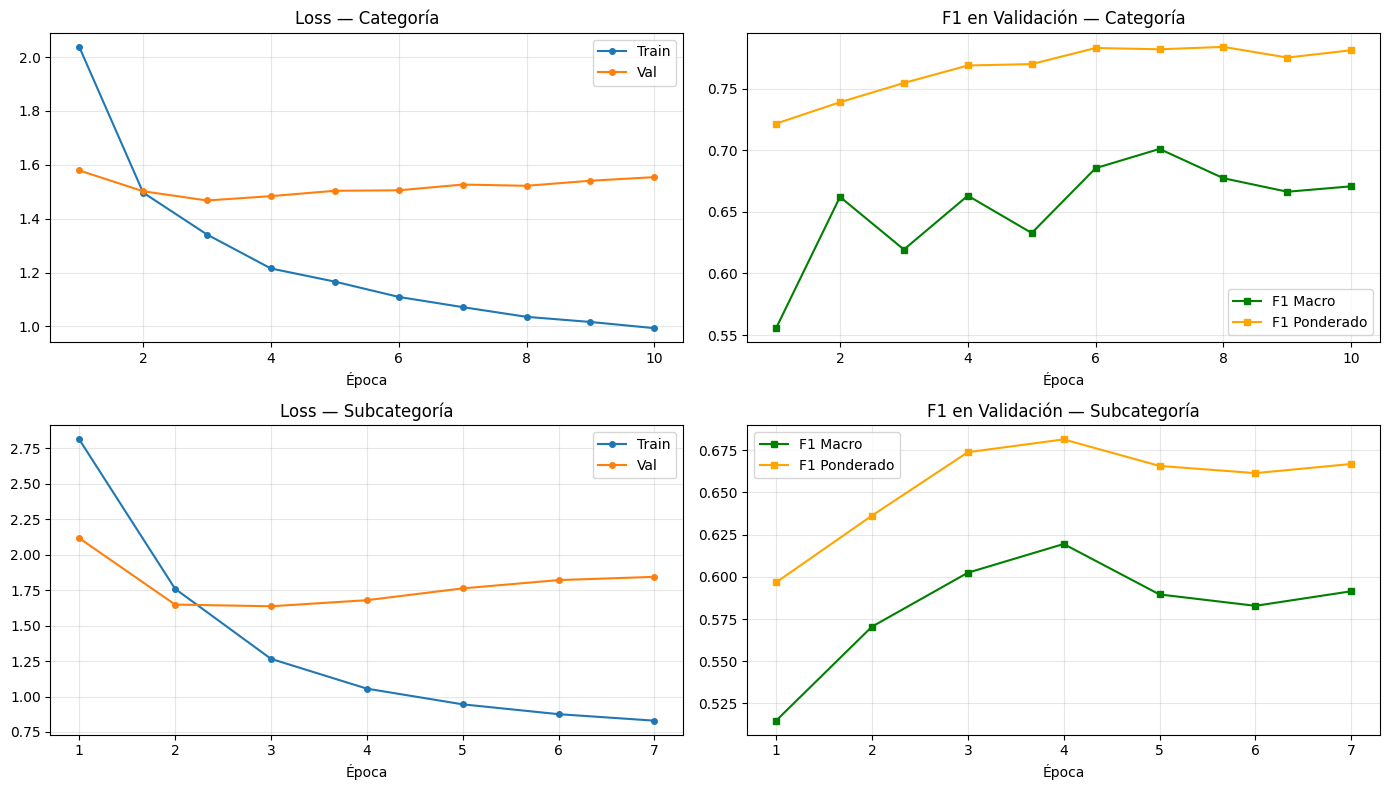

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (history, titulo) in enumerate([(history_cat, 'Categoría'),
                                         (history_sub, 'Subcategoría')]):
    epocas = range(1, len(history['train_loss']) + 1)

    axes[i][0].plot(epocas, history['train_loss'], label='Train', marker='o', markersize=4)
    axes[i][0].plot(epocas, history['val_loss'],   label='Val',   marker='o', markersize=4)
    axes[i][0].set_title(f'Loss — {titulo}')
    axes[i][0].set_xlabel('Época')
    axes[i][0].legend()
    axes[i][0].grid(True, alpha=0.3)

    axes[i][1].plot(epocas, history['val_f1_macro'], label='F1 Macro',     marker='s', markersize=4, color='green')
    axes[i][1].plot(epocas, history['val_f1_pond'],  label='F1 Ponderado', marker='s', markersize=4, color='orange')
    axes[i][1].set_title(f'F1 en Validación — {titulo}')
    axes[i][1].set_xlabel('Época')
    axes[i][1].legend()
    axes[i][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_aprendizaje_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 19 — Evaluación final en conjunto de prueba

Evalúa ambos modelos sobre el conjunto de prueba (nunca visto durante el entrenamiento).  
Reporta accuracy, F1 Macro, F1 Ponderado y reporte completo por clase.

In [ ]:
print('=== RESULTADOS FINALES EN CONJUNTO DE PRUEBA ===\n')

# Categoría
loss, acc, f1m, f1p, preds_cat, labels_cat = evaluar(
    model_cat, test_cat, criterion_cat, model_cat_ref=None)
print('--- CATEGORÍA ---')
print(f'  Loss:         {loss:.4f}')
print(f'  Accuracy:     {acc*100:.2f}%')
print(f'  F1 Macro:     {f1m:.4f}')
print(f'  F1 Ponderado: {f1p:.4f}')
print(f'\n  Reporte por clase:')
print(classification_report(labels_cat, preds_cat,
      target_names=le_cat.classes_, zero_division=0))

# Subcategoría
loss, acc, f1m, f1p, preds_sub, labels_sub = evaluar(
    model_sub, test_sub, criterion_sub, model_cat_ref=model_cat)
print('--- SUBCATEGORÍA ---')
print(f'  Loss:         {loss:.4f}')
print(f'  Accuracy:     {acc*100:.2f}%')
print(f'  F1 Macro:     {f1m:.4f}')
print(f'  F1 Ponderado: {f1p:.4f}')
print(f'\n  Reporte por clase:')
print(classification_report(labels_sub, preds_sub,
      target_names=le_sub.classes_, zero_division=0))

=== RESULTADOS FINALES EN CONJUNTO DE PRUEBA ===

--- CATEGORÍA ---
  Loss:         1.5950
  Accuracy:     76.05%
  F1 Macro:     0.6529
  F1 Ponderado: 0.7677

  Reporte por clase:
                                       precision    recall  f1-score   support

                     Acciones armadas       0.70      0.62      0.66       114
Ataque a objetivos ilícitos de guerra       0.33      0.56      0.42         9
    Ataques contra la población civil       0.92      0.87      0.90       297
           Categorías Complementarias       0.64      0.78      0.70         9
               Desplazamiento forzado       0.45      0.69      0.54        49
    Restricción al acceso humanitario       0.76      0.67      0.71        92
         Uso de artefactos explosivos       0.62      0.67      0.64        48

                             accuracy                           0.76       618
                            macro avg       0.63      0.69      0.65       618
                         w

## Celda 20 — Matrices de confusión normalizadas

Matrices normalizadas por fila: cada fila indica qué fracción de predicciones
fue correcta por clase real. Útil para identificar confusiones sistemáticas.

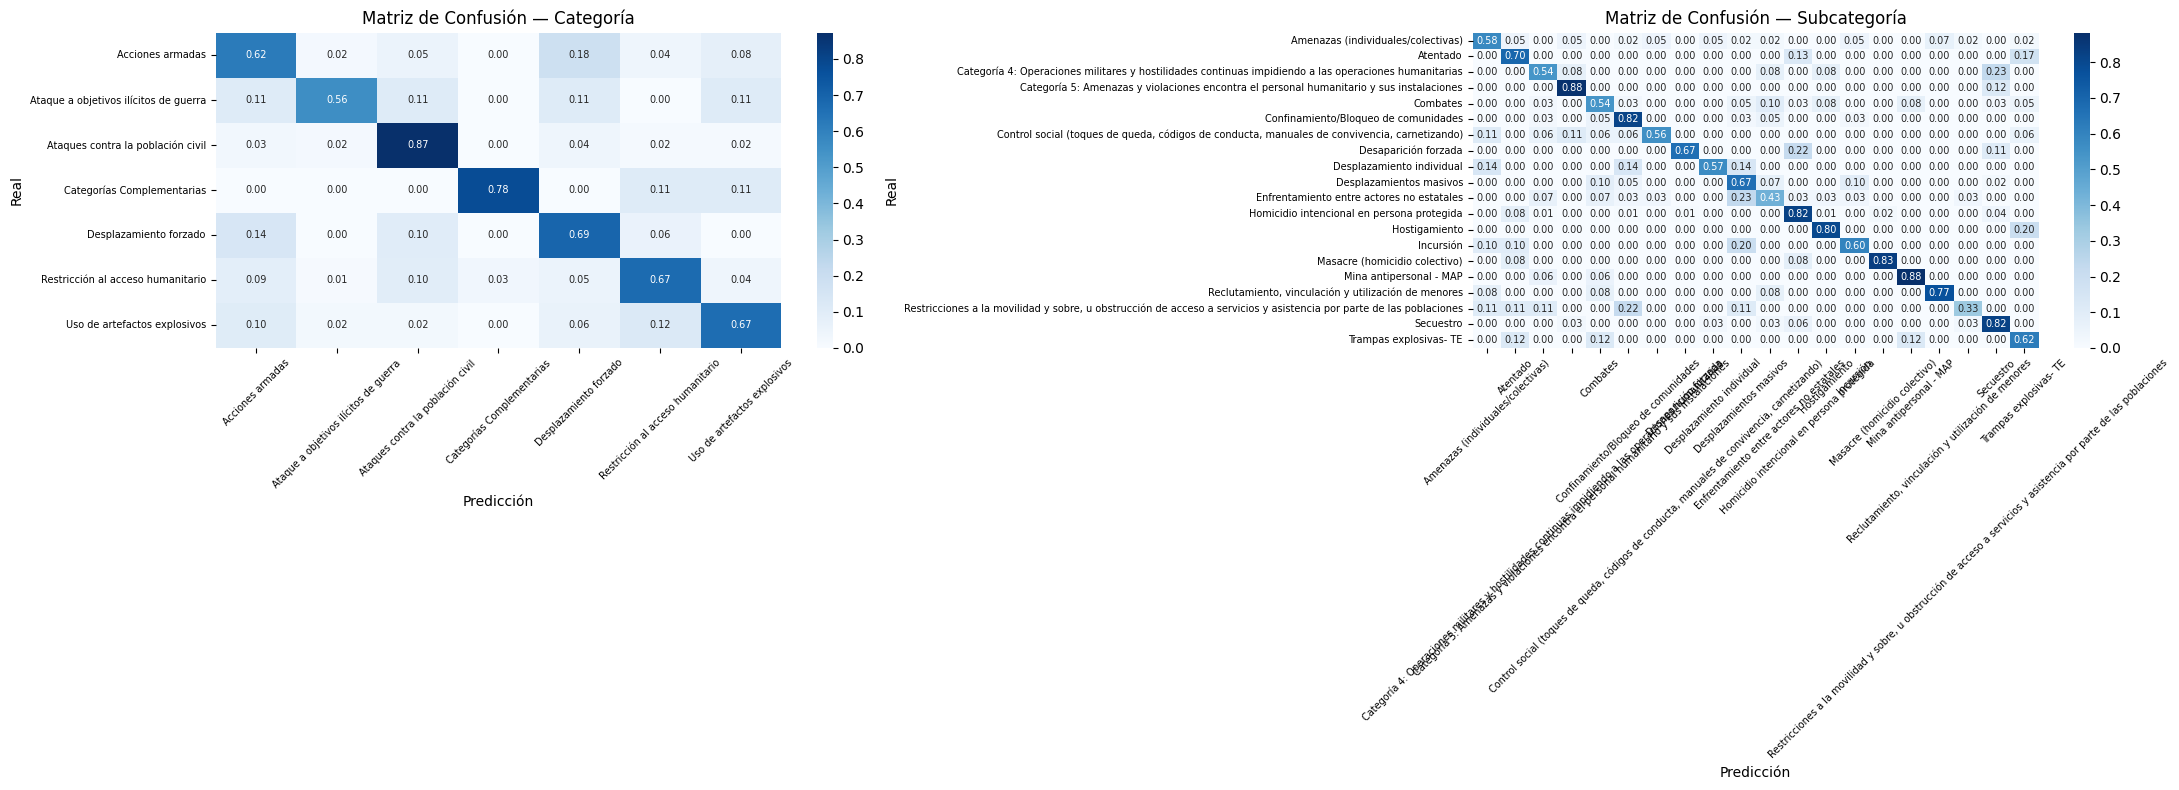

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, preds, labels, le, nombre in [
    (axes[0], preds_cat, labels_cat, le_cat, 'Categoría'),
    (axes[1], preds_sub, labels_sub, le_sub, 'Subcategoría'),
]:
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, annot_kws={'size': 7})
    ax.set_title(f'Matriz de Confusión — {nombre}', fontsize=12)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('matrices_confusion_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
## Celda 20B — Análisis de errores en clases problemáticas

import textwrap

def analizar_errores(preds, labels, le, textos_test, clase_a=None, clase_b=None, n=20):
    """
    Muestra los N ejemplos donde el modelo confunde clase_a con clase_b (y viceversa).
    Si no se especifican clases, muestra todos los errores ordenados por par de confusión.
    """
    errores = []
    for i, (pred, real) in enumerate(zip(preds, labels)):
        if pred == real:
            continue
        nombre_pred = le.classes_[pred]
        nombre_real = le.classes_[real]

        # Filtrar por par específico si se pide
        if clase_a and clase_b:
            par = {nombre_pred, nombre_real}
            if par != {clase_a, clase_b}:
                continue

        errores.append({
            'texto':      textos_test[i],
            'real':       nombre_real,
            'prediccion': nombre_pred,
        })

    print(f'Total de errores encontrados: {len(errores)}')
    print('=' * 80)

    for j, e in enumerate(errores[:n], 1):
        print(f'\n[{j}] REAL: {e["real"]}  →  PREDICCIÓN: {e["prediccion"]}')
        print('-' * 60)
        for linea in textwrap.wrap(e['texto'], width=78):
            print(' ', linea)

    # Resumen de los pares de confusión más frecuentes
    from collections import Counter
    pares = Counter(
        (le.classes_[r], le.classes_[p])
        for r, p in zip(labels, preds) if r != p
    )
    print('\n\n=== TOP 15 PARES DE CONFUSIÓN ===')
    print(f'{"Real":<35} {"Predicción":<35} {"N":>5}')
    print('-' * 78)
    for (real, pred), count in pares.most_common(15):
        print(f'{real:<35} {pred:<35} {count:>5}')


# ── Resumen general de errores de subcategoría ──────────────────────────────
analizar_errores(preds_sub, labels_sub, le_sub, X_sub_test)

# ── Zoom en el par más problemático (ajusta los nombres según tus clases) ───
# Descomenta y edita con los nombres exactos que aparecen en le_sub.classes_
# analizar_errores(
#     preds_sub, labels_sub, le_sub, X_sub_test,
#     clase_a='Ataque a objetivos ilícitos',
#     clase_b='Acciones armadas',
#     n=30
# )

Total de errores encontrados: 162

[1] REAL: Homicidio intencional en persona protegida  →  PREDICCIÓN: Atentado
------------------------------------------------------------
  "En las últimas horas se confirmó el asesinato del líder social y cultural
  Andrés Alberto Erazo Pérez. Los mortales hechos sucedieron este sábado 5 de
  octubre en inmediaciones del parque principal de este municipio, cuando
  sujetos armados atacaron a Andrés Alberto Erazo Pérez, quien era además
  integrante de la Defensa Civil de este poblado"

[2] REAL: Homicidio intencional en persona protegida  →  PREDICCIÓN: Atentado
------------------------------------------------------------
  El hecho se habría registrado sobre las 10:20 pm la noche de este domingo, en
  el establecimiento de razón social LA CANTINA 17. Hasta este lugar habría
  llegado una persona quien habría atentado con arma de fuego en al menos 10
  oportunidades contra otra de sexo masculino de nombre al parecer MILLER HERNAN
  ORDÓÑEZ, quien se

## Celda 21 — Guardado del modelo

Guarda los modelos entrenados y el tokenizador para uso futuro o despliegue.

In [ ]:
import os
SAVE_DIR = '/content/drive/MyDrive/modelos_violencia_roberta'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model_cat.state_dict(), f'{SAVE_DIR}/model_cat.pt')
torch.save(model_sub.state_dict(), f'{SAVE_DIR}/model_sub.pt')
tokenizer.save_pretrained(f'{SAVE_DIR}/tokenizer')

# Guardar también los LabelEncoders
import pickle
with open(f'{SAVE_DIR}/le_cat.pkl', 'wb') as f: pickle.dump(le_cat, f)
with open(f'{SAVE_DIR}/le_sub.pkl', 'wb') as f: pickle.dump(le_sub, f)

print(f'Modelos guardados en {SAVE_DIR}')

## Celda 22 — Función de predicción para texto nuevo

Interface de inferencia final. Dado cualquier texto en español:
1. Lo tokeniza con el tokenizador RoBERTa.
2. Obtiene los logits de categoría.
3. Pasa esos logits al modelo de subcategoría.
4. Imprime categoría y subcategoría con su probabilidad de confianza.

In [ ]:
def predecir(texto):
    """Predice tipo y subtipo de violencia para un texto nuevo."""    enc = tokenizer(
        texto,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    model_cat.eval()
    model_sub.eval()
    with torch.no_grad():
        logits_cat = model_cat(input_ids, attention_mask)
        extra      = F.softmax(logits_cat, dim=1)
        logits_sub = model_sub(input_ids, attention_mask, extra=extra)

    prob_cat = F.softmax(logits_cat, dim=1).cpu().numpy()[0]
    prob_sub = F.softmax(logits_sub, dim=1).cpu().numpy()[0]

    print(f'Texto: "{texto[:120].strip()}"')
    print(f'  → Tipo:    {le_cat.classes_[prob_cat.argmax()]}  ({prob_cat.max()*100:.1f}%)')
    print(f'  → Subtipo: {le_sub.classes_[prob_sub.argmax()]}  ({prob_sub.max()*100:.1f}%)')
    print()


predecir("""El pasado lunes integrantes del ELN atacaron una patrulla del ejército en zona
rural del municipio de Tibú, Norte de Santander, resultando heridos tres
uniformados y obligando a varias familias campesinas a desplazarse.""")

predecir("""Una mujer de 32 años fue asesinada de varios disparos por hombres armados
que llegaron en moto al barrio Comuneros de Cúcuta en la madrugada del domingo.""")

predecir("""Comunidades indígenas del resguardo Zenú denunciaron amenazas de grupos
armados que les exigen abandonar su territorio en el sur de Córdoba.""")